
# CS729 Question 1: Final Notebook

This notebook implements a clean and reproducible solution for **Question 1** using the **MNIST** dataset and a **feed-forward neural network**.

It includes:
- non-private **SGD** and **Adam** baselines,
- private **DP-SGD** and **DP-Adam** experiments for target $\epsilon \in \{1, 10\}$,
- convergence plots using iteration-level training loss,
- privacy-spent vs epochs plots,
- target-epsilon vs test-accuracy comparison,
- a compact results table and short discussion.

For Question 1, we keep the privacy accountant fixed to **RDP** so that the comparison stays focused on the **optimizer effect**. A full accountant comparison belongs naturally to **Question 2**.


In [1]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 14.6 MB/s eta 0:00:00


In [2]:

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from IPython.display import display
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from opacus import PrivacyEngine

plt.style.use("seaborn-v0_8-whitegrid")



## 1. Configuration and Reproducibility

We fix all key hyperparameters in one place and seed the experiment for reproducibility.


In [3]:

SEED = 42
BATCH_SIZE = 64
TEST_BATCH_SIZE = 1024
EPOCHS = 10
DELTA = 1e-5
TARGET_EPSILONS = [1, 10]
MAX_GRAD_NORM = 1.0
LR_SGD = 0.1
LR_ADAM = 1e-3
ACCOUNTANT = "rdp"
SMOOTHING_WINDOW = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)
print(f"Using device: {DEVICE}")
print(f"Accountant used for Q1: {ACCOUNTANT}")


Using device: cuda
Accountant used for Q1: rdp



## 2. Data Loading

We load MNIST once and create helper functions for fresh train loaders so every experiment starts from a clean, reproducible state.


In [4]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)


def make_train_loader(seed: int = SEED, shuffle: bool = True) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


def make_test_loader() -> DataLoader:
    return DataLoader(
        test_dataset,
        batch_size=TEST_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


base_train_loader = make_train_loader()
test_loader = make_test_loader()

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batches per epoch (non-private loader): {len(base_train_loader)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 134MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 40.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 36.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.01MB/s]


Training samples: 60000
Test samples: 10000
Batches per epoch (non-private loader): 938



## 3. Model Definition

A simple feed-forward neural network as required in the assignment.


In [5]:

class MNIST_FFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


def build_model() -> nn.Module:
    return MNIST_FFNN().to(DEVICE)


def build_optimizer(opt_name: str, model: nn.Module):
    if opt_name == "SGD":
        return optim.SGD(model.parameters(), lr=LR_SGD)
    if opt_name == "Adam":
        return optim.Adam(model.parameters(), lr=LR_ADAM)
    raise ValueError(f"Unsupported optimizer: {opt_name}")



## 4. Training and Evaluation Utilities

We record both **iteration-level** and **epoch-level** training loss. The evaluation function returns correctly normalized test loss and test accuracy.


In [6]:

def train_one_epoch(model, train_loader, optimizer, device=DEVICE, privacy_engine=None, start_iteration=0):
    model.train()
    criterion = nn.CrossEntropyLoss()

    iteration_losses = []
    iteration_steps = []
    running_loss = 0.0
    num_examples = 0
    iteration = start_iteration
    
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        batch_size = data.size(0)
        iteration += 1
        iteration_steps.append(iteration)
        iteration_losses.append(loss_value)
        running_loss += loss_value * batch_size
        num_examples += batch_size

    epoch_loss = running_loss / max(num_examples, 1)
    epsilon = None if privacy_engine is None else privacy_engine.get_epsilon(DELTA)
    return iteration_steps, iteration_losses, epoch_loss, epsilon


@torch.no_grad()
def evaluate(model, data_loader, device=DEVICE):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")

    total_loss = 0.0
    correct = 0
    total_examples = 0

    for data, target in data_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        total_loss += criterion(output, target).item()
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total_examples += target.size(0)

    avg_loss = total_loss / max(total_examples, 1)
    accuracy = 100.0 * correct / max(total_examples, 1)
    return avg_loss, accuracy


def smooth_curve(values, window=SMOOTHING_WINDOW):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values
    if len(values) < window:
        return values
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")



## 5. Experiment Runners

Each run starts from the same seed so optimizer comparisons are fair and reproducible.


In [7]:

def run_non_private_experiment(opt_name: str, epochs: int = EPOCHS, seed: int = SEED):
    seed_everything(seed)
    model = build_model()
    optimizer = build_optimizer(opt_name, model)
    train_loader = make_train_loader(seed=seed, shuffle=True)
    test_loader = make_test_loader()

    metrics = {
    "optimizer": opt_name,
    "private": False,
    "target_epsilon": np.inf,
    "noise_multiplier": None,
    "iteration_steps": [],
    "iteration_losses": [],
    "epoch_losses": [],
    "epsilons": [],
    "test_losses": [],
    "test_accuracies": [],
    }

    global_iteration = 0
    
    for epoch in range(1, epochs + 1):
        iter_steps, iter_losses, epoch_loss, _ = train_one_epoch(
            model,
            train_loader,
            optimizer,
            DEVICE,
            privacy_engine=None,
            start_iteration=global_iteration,
        )

        global_iteration = iter_steps[-1] 
        
        test_loss, test_acc = evaluate(model, test_loader, DEVICE)

        metrics["iteration_steps"].extend(iter_steps)
        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(np.inf)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)

        print(
            f"[Non-Private {opt_name}] Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {epoch_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
        )

    metrics["final_test_loss"] = metrics["test_losses"][-1]
    metrics["final_accuracy"] = metrics["test_accuracies"][-1]
    metrics["final_epsilon"] = np.inf
    return metrics



def run_private_experiment(opt_name: str, target_epsilon: float, epochs: int = EPOCHS, seed: int = SEED):
    seed_everything(seed)
    model = build_model()
    optimizer = build_optimizer(opt_name, model)
    train_loader = make_train_loader(seed=seed, shuffle=True)
    test_loader = make_test_loader()

    privacy_engine = PrivacyEngine(accountant=ACCOUNTANT)
    model, optimizer, private_train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        target_epsilon=target_epsilon,
        target_delta=DELTA,
        epochs=epochs,
        max_grad_norm=MAX_GRAD_NORM,
    )

    metrics = {
        "optimizer": opt_name,
        "private": True,
        "target_epsilon": target_epsilon,
        "noise_multiplier": getattr(privacy_engine, "noise_multiplier", None),
        "iteration_losses": [],
        "epoch_losses": [],
        "epsilons": [],
        "test_losses": [],
        "test_accuracies": [],
        "iteration_steps": [],
    }

    global_iteration = 0
    for epoch in range(1, epochs + 1):
        iter_steps, iter_losses, epoch_loss, epsilon = train_one_epoch(
            model,
            private_train_loader,
            optimizer,
            DEVICE,
            privacy_engine=privacy_engine,
            start_iteration=global_iteration,
        )
        global_iteration = iter_steps[-1]
        test_loss, test_acc = evaluate(model, test_loader, DEVICE)

        metrics["iteration_steps"].extend(iter_steps)
        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(epsilon)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)

        print(
            f"[DP-{opt_name} | target eps={target_epsilon}] Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {epoch_loss:.4f} | Epsilon Spent: {epsilon:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
        )

    metrics["final_test_loss"] = metrics["test_losses"][-1]
    metrics["final_accuracy"] = metrics["test_accuracies"][-1]
    metrics["final_epsilon"] = metrics["epsilons"][-1]
    return metrics



## 6. Run the Full Experiment Grid

This cell runs all six configurations required for Question 1:
- non-private SGD,
- non-private Adam,
- DP-SGD with target $\epsilon=1$ and $\epsilon=10$,
- DP-Adam with target $\epsilon=1$ and $\epsilon=10$.


In [8]:

results = {}

results["SGD_non_private"] = run_non_private_experiment("SGD")
results["Adam_non_private"] = run_non_private_experiment("Adam")

for eps in TARGET_EPSILONS:
    results[f"SGD_dp_eps{eps}"] = run_private_experiment("SGD", target_epsilon=eps)
    results[f"Adam_dp_eps{eps}"] = run_private_experiment("Adam", target_epsilon=eps)

print("All Question 1 experiments completed.")


[Non-Private SGD] Epoch 01/10 | Train Loss: 0.2690 | Test Loss: 0.1184 | Test Acc: 96.29%
[Non-Private SGD] Epoch 02/10 | Train Loss: 0.0971 | Test Loss: 0.0914 | Test Acc: 97.09%
[Non-Private SGD] Epoch 03/10 | Train Loss: 0.0621 | Test Loss: 0.0873 | Test Acc: 97.06%
[Non-Private SGD] Epoch 04/10 | Train Loss: 0.0418 | Test Loss: 0.0653 | Test Acc: 97.95%
[Non-Private SGD] Epoch 05/10 | Train Loss: 0.0295 | Test Loss: 0.0649 | Test Acc: 97.95%
[Non-Private SGD] Epoch 06/10 | Train Loss: 0.0198 | Test Loss: 0.0666 | Test Acc: 97.91%
[Non-Private SGD] Epoch 07/10 | Train Loss: 0.0132 | Test Loss: 0.1386 | Test Acc: 96.12%
[Non-Private SGD] Epoch 08/10 | Train Loss: 0.0089 | Test Loss: 0.0645 | Test Acc: 98.16%
[Non-Private SGD] Epoch 09/10 | Train Loss: 0.0061 | Test Loss: 0.0681 | Test Acc: 98.04%
[Non-Private SGD] Epoch 10/10 | Train Loss: 0.0037 | Test Loss: 0.0600 | Test Acc: 98.34%
[Non-Private Adam] Epoch 01/10 | Train Loss: 0.2047 | Test Loss: 0.1133 | Test Acc: 96.37%
[Non-Priv

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[DP-SGD | target eps=1] Epoch 01/10 | Train Loss: 0.7405 | Epsilon Spent: 0.8431 | Test Loss: 0.4507 | Test Acc: 88.32%
[DP-SGD | target eps=1] Epoch 02/10 | Train Loss: 0.5011 | Epsilon Spent: 0.8607 | Test Loss: 0.5117 | Test Acc: 88.92%
[DP-SGD | target eps=1] Epoch 03/10 | Train Loss: 0.5829 | Epsilon Spent: 0.8783 | Test Loss: 0.5655 | Test Acc: 89.28%
[DP-SGD | target eps=1] Epoch 04/10 | Train Loss: 0.6619 | Epsilon Spent: 0.8960 | Test Loss: 0.6703 | Test Acc: 88.78%
[DP-SGD | target eps=1] Epoch 05/10 | Train Loss: 0.7596 | Epsilon Spent: 0.9136 | Test Loss: 0.8196 | Test Acc: 87.81%
[DP-SGD | target eps=1] Epoch 06/10 | Train Loss: 0.8524 | Epsilon Spent: 0.9307 | Test Loss: 0.8640 | Test Acc: 87.97%
[DP-SGD | target eps=1] Epoch 07/10 | Train Loss: 1.0097 | Epsilon Spent: 0.9467 | Test Loss: 1.0128 | Test Acc: 87.57%
[DP-SGD | target eps=1] Epoch 08/10 | Train Loss: 1.0933 | Epsilon Spent: 0.9626 | Test Loss: 1.1329 | Test Acc: 87.18%
[DP-SGD | target eps=1] Epoch 09/10 | Tr


## 7. Results Summary Table


In [9]:

summary_rows = []
for run_name, metrics in results.items():
    summary_rows.append({
        "Run": run_name,
        "Optimizer": metrics["optimizer"],
        "Private": metrics["private"],
        "Target Epsilon": metrics["target_epsilon"],
        "Final Epsilon Spent": metrics["final_epsilon"],
        "Noise Multiplier": metrics["noise_multiplier"],
        "Final Test Loss": metrics["final_test_loss"],
        "Final Test Accuracy (%)": metrics["final_accuracy"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by=["Private", "Optimizer", "Target Epsilon"]).reset_index(drop=True)

display_df = summary_df.copy()
display_df["Target Epsilon"] = display_df["Target Epsilon"].replace(np.inf, "non-private")
display_df["Final Epsilon Spent"] = display_df["Final Epsilon Spent"].apply(
    lambda x: "inf" if np.isinf(x) else round(float(x), 4)
)
display_df["Noise Multiplier"] = display_df["Noise Multiplier"].apply(
    lambda x: "-" if x is None else round(float(x), 4)
)
display_df["Final Test Loss"] = display_df["Final Test Loss"].round(4)
display_df["Final Test Accuracy (%)"] = display_df["Final Test Accuracy (%)"].round(2)

display(display_df)


,Run,Optimizer,Private,Target Epsilon,Final Epsilon Spent,Noise Multiplier,Final Test Loss,Final Test Accuracy (%)
0,Adam_non_private,Adam,False,non-private,inf,-,0.0819,98.11
1,SGD_non_private,SGD,False,non-private,inf,-,0.0600,98.34
2,Adam_dp_eps1,Adam,True,1.0,0.994,-,0.6516,89.62
3,Adam_dp_eps10,Adam,True,10.0,9.9927,-,0.5275,91.95
4,SGD_dp_eps1,SGD,True,1.0,0.994,-,1.3028,87.17
5,SGD_dp_eps10,SGD,True,10.0,9.9927,-,0.4137,92.39



## 8. Plot (a): Number of Iterations vs Training Loss


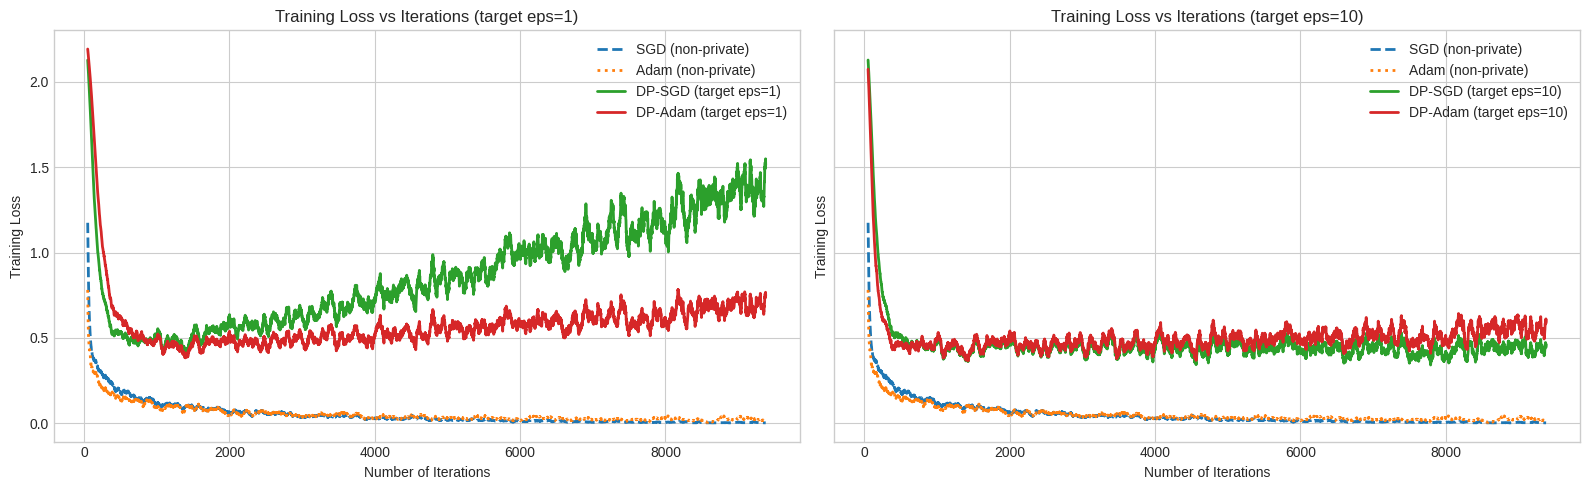

In [10]:

def plot_smoothed(ax, steps, values, label, linestyle="-", color=None):
    smoothed = smooth_curve(values)
    if len(smoothed) == 0:
        return
    aligned_steps = np.asarray(steps[-len(smoothed):])
    ax.plot(aligned_steps, smoothed, label=label, linestyle=linestyle, linewidth=2, color=color)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, eps in zip(axes, TARGET_EPSILONS):
    plot_smoothed(
        ax,
        results["SGD_non_private"]["iteration_steps"],
        results["SGD_non_private"]["iteration_losses"],
        "SGD (non-private)",
        linestyle="--",
    )
    plot_smoothed(
        ax,
        results["Adam_non_private"]["iteration_steps"],
        results["Adam_non_private"]["iteration_losses"],
        "Adam (non-private)",
        linestyle=":",
    )
    plot_smoothed(
        ax,
        results[f"SGD_dp_eps{eps}"]["iteration_steps"],
        results[f"SGD_dp_eps{eps}"]["iteration_losses"],
        f"DP-SGD (target eps={eps})",
    )
    plot_smoothed(
        ax,
        results[f"Adam_dp_eps{eps}"]["iteration_steps"],
        results[f"Adam_dp_eps{eps}"]["iteration_losses"],
        f"DP-Adam (target eps={eps})",
    )
    ax.set_title(f"Training Loss vs Iterations (target eps={eps})")
    ax.set_xlabel("Number of Iterations")
    ax.set_ylabel("Training Loss")
    ax.legend()

plt.tight_layout()
plt.show()



## 9. Plot (b): Epsilon Spent vs Epochs

We compare the privacy budget consumed by DP-SGD and DP-Adam under the same target epsilon.


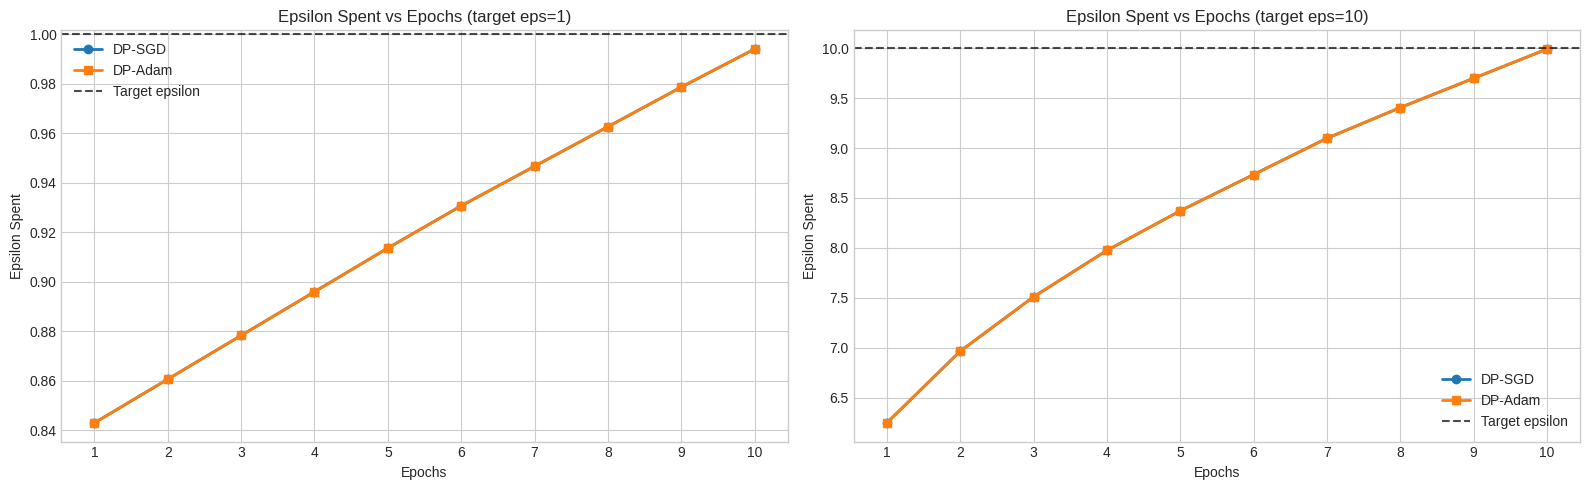

In [11]:

epoch_axis = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, eps in zip(axes, TARGET_EPSILONS):
    ax.plot(epoch_axis, results[f"SGD_dp_eps{eps}"]["epsilons"], marker="o", linewidth=2, label="DP-SGD")
    ax.plot(epoch_axis, results[f"Adam_dp_eps{eps}"]["epsilons"], marker="s", linewidth=2, label="DP-Adam")
    ax.axhline(eps, color="black", linestyle="--", linewidth=1.5, alpha=0.7, label="Target epsilon")
    ax.set_title(f"Epsilon Spent vs Epochs (target eps={eps})")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Epsilon Spent")
    ax.set_xticks(epoch_axis)
    ax.legend()

plt.tight_layout()
plt.show()



## 10. Plot (c): Target Epsilon vs Test Accuracy

We compare private and non-private utility for both optimizers.


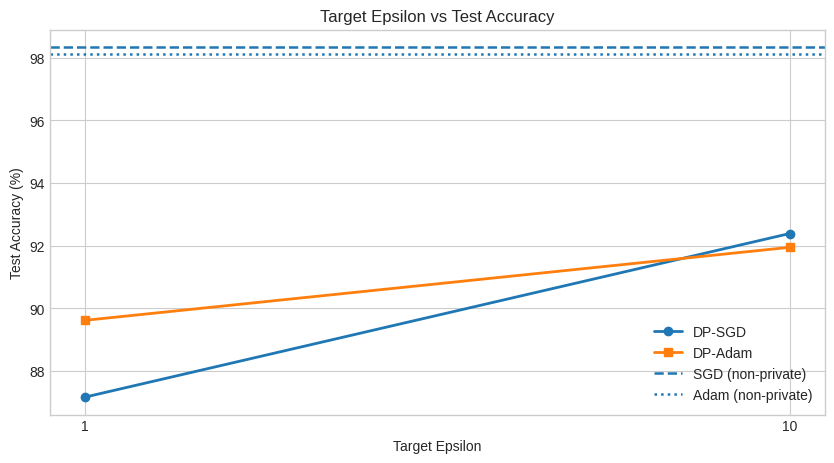

In [12]:
eps_values = np.array(TARGET_EPSILONS)

sgd_dp_accs = [
    results["SGD_dp_eps1"]["final_accuracy"],
    results["SGD_dp_eps10"]["final_accuracy"],
]
adam_dp_accs = [
    results["Adam_dp_eps1"]["final_accuracy"],
    results["Adam_dp_eps10"]["final_accuracy"],
]

plt.figure(figsize=(10, 5))
plt.plot(eps_values, sgd_dp_accs, marker="o", linewidth=2, label="DP-SGD")
plt.plot(eps_values, adam_dp_accs, marker="s", linewidth=2, label="DP-Adam")

plt.axhline(
    results["SGD_non_private"]["final_accuracy"],
    linestyle="--",
    linewidth=1.8,
    label="SGD (non-private)",
)
plt.axhline(
    results["Adam_non_private"]["final_accuracy"],
    linestyle=":",
    linewidth=1.8,
    label="Adam (non-private)",
)

plt.xticks(eps_values, [str(eps) for eps in eps_values])
plt.xlabel("Target Epsilon")
plt.ylabel("Test Accuracy (%)")
plt.title("Target Epsilon vs Test Accuracy")
plt.legend()
plt.show()

### Observations
- Adam converges faster than SGD in the non-private setting.
- Differential privacy slows convergence and introduces additional noise in the optimization process.
- For both optimizers, the run with target epsilon = 10 achieves better test accuracy than the run with target epsilon = 1, showing the standard privacy–utility tradeoff.
- The epsilon spent increases monotonically with training epochs.
- The non-private models achieve the highest final accuracy, while the private models sacrifice some utility in exchange for privacy guarantees.


## 11. Short Discussion

### Accountant Used
We use the **RDP accountant** provided by Opacus to track privacy expenditure. At every epoch, epsilon spent is computed using the fixed delta value chosen for the experiment.

### Note on DP-Adam
We apply the Opacus privacy mechanism to the Adam optimizer as required in the assignment. While DP-SGD is the standard and most commonly analyzed private optimizer, this experiment also compares the behavior of Adam under the same privacy mechanism.

In [13]:

private_run_names = [name for name, metrics in results.items() if metrics["private"]]
best_private_run = max(private_run_names, key=lambda name: results[name]["final_accuracy"])

print(f"Accountant used throughout Q1: {ACCOUNTANT}")
print(f"Delta used throughout Q1: {DELTA}")
print(f"Best private run by final test accuracy: {best_private_run}")
print(f"Best private accuracy: {results[best_private_run]['final_accuracy']:.2f}%")

Accountant used throughout Q1: rdp
Delta used throughout Q1: 1e-05
Best private run by final test accuracy: SGD_dp_eps10
Best private accuracy: 92.39%
